In [1]:
# ============================================================
# NOTEBOOK 3 — Explainability avec SHAP
# Models : Random Forest + Logistic Regression
# Dataset : Breast Cancer
# ============================================================

import shap
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

shap.initjs()


1. Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)


In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# explainer_rf = shap.TreeExplainer(rf)
# shap_values_rf = explainer_rf.shap_values(X_test)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


3. SHAP summary plot (RF)

In [4]:
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)    
# explainer_rf = shap.TreeExplainer(rf)
# shap_values = explainer_rf(X_test)


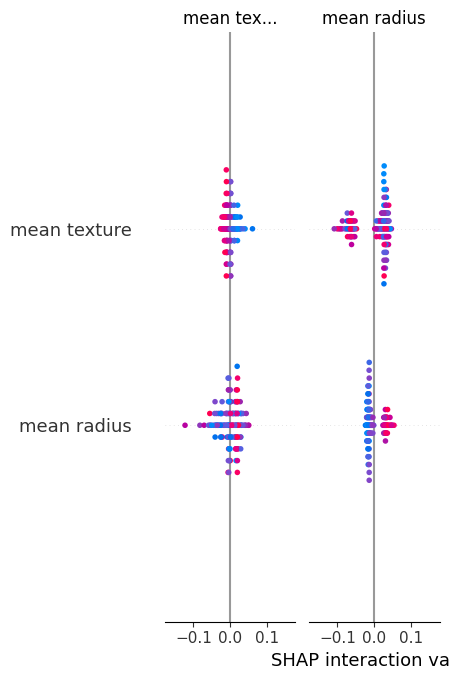

In [5]:
shap.summary_plot(shap_values_rf[:], X_test, plot_type="dot", show=True)


4. Logistic Regression + LinearExplainer

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_scaled, y_train)

explainer_lr = shap.LinearExplainer(logreg, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)


5. SHAP summary plot (LogReg)

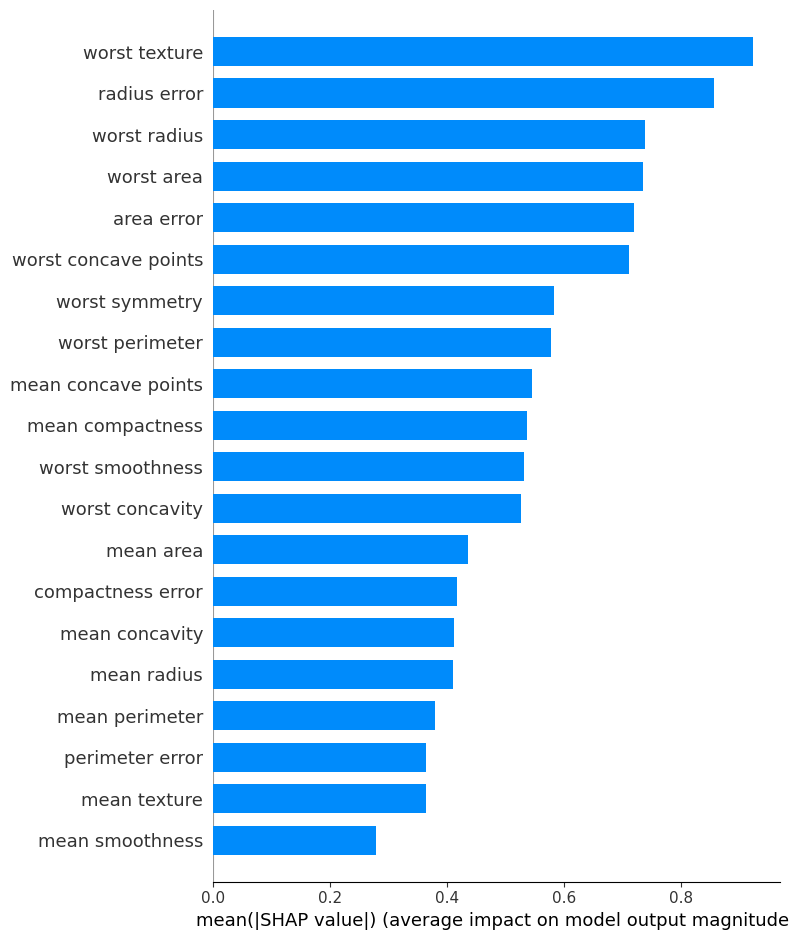

In [7]:
shap.summary_plot(shap_values_lr, X_test, plot_type="bar")


1️⃣ Compare SHAP RF vs SHAP Logistic :
      → Quelles variables dominent ?

2️⃣ Visualise un force_plot pour 5 individus.

3️⃣ Définis une pipeline :
        scaler + PCA + logistic
      → Analyse SHAP

4️⃣ Interprète la feature 'mean radius' :
      → Comment influence-t-elle le modèle ?

## 1. Compare SHAP RF vs SHAP Logistic

In [8]:
# Define a fonction: return a SHAP array of (n_samples, n_features) -> To ensure compatibility between the old and new versions of SHAP
def shap_to_2d(shap_obj, class_idx=1):
    """
    Convert SHAP output to a 2D numpy array (n_samples, n_features).
    Supports:
      - list of arrays (one per class)
      - shap.Explanation (uses .values)
      - numpy arrays shaped (n,p) or (n,p,k)
    """
    if isinstance(shap_obj, list):
        vals = np.asarray(shap_obj[class_idx])
    elif hasattr(shap_obj, "values"):
        vals = np.asarray(shap_obj.values)
    else:
        vals = np.asarray(shap_obj)

    if vals.ndim == 3:
        vals = vals[:, :, class_idx]
    elif vals.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {vals.shape}")

    return vals


rf_vals = shap_to_2d(shap_values_rf, class_idx=1)  
lr_vals = shap_to_2d(shap_values_lr, class_idx=1)  

rf_mean_abs = np.abs(rf_vals).mean(axis=0)
lr_mean_abs = np.abs(lr_vals).mean(axis=0)

feat_names = X.columns.to_list()

top_n = 10
rf_top = pd.Series(rf_mean_abs, index=feat_names).sort_values(ascending=False).head(top_n)
lr_top = pd.Series(lr_mean_abs, index=feat_names).sort_values(ascending=False).head(top_n)

compare_df = pd.DataFrame({
    "RF mean(|SHAP|) (class=benign)": rf_top,
    "LR mean(|SHAP|)": lr_top
}).fillna(0)

compare_df


,RF mean(|SHAP|) (class=benign),LR mean(|SHAP|)
area error,0.000000,0.720014
mean area,0.021765,0.000000
mean compactness,0.000000,0.537333
mean concave points,0.048406,0.545194
mean concavity,0.024347,0.000000
mean perimeter,0.026274,0.000000
mean radius,0.020304,0.000000
radius error,0.000000,0.856193
worst area,0.069262,0.735531
worst concave points,0.051065,0.710145


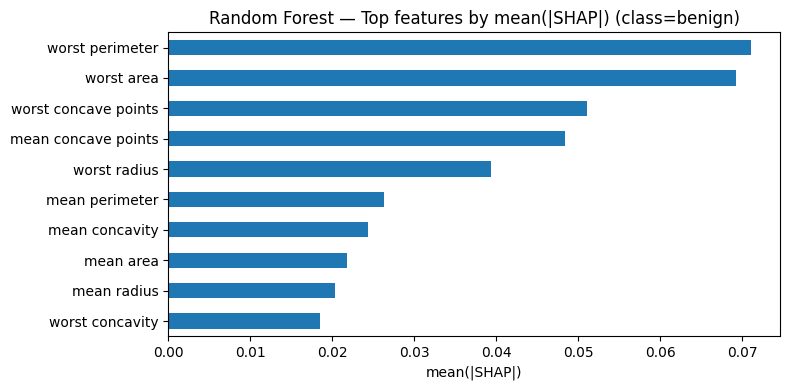

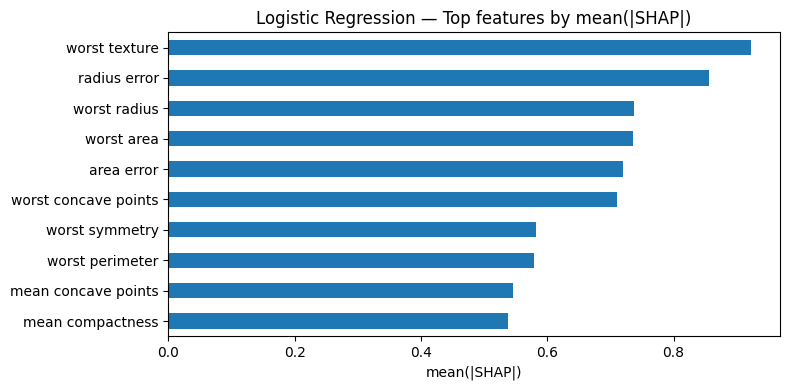

In [9]:
# Visual comparison 
plt.figure(figsize=(8, 4))
rf_top.sort_values().plot(kind="barh")
plt.title("Random Forest — Top features by mean(|SHAP|) (class=benign)")
plt.xlabel("mean(|SHAP|)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
lr_top.sort_values().plot(kind="barh")
plt.title("Logistic Regression — Top features by mean(|SHAP|)")
plt.xlabel("mean(|SHAP|)")
plt.tight_layout()
plt.show()

According to RF, the important features are `worst perimeter` and `worst area`; According to LR, the important features are `worst texture` and `radius errur`.

## 2. Visualise un force_plot pour 5 individus

In [10]:
# Define a fonction: return a float -> To ensure compatibility between the old and new versions of SHAP
def get_base_value_for_class(shap_obj, explainer, i, class_idx=1):
    if hasattr(shap_obj, "base_values"):
        bv = np.asarray(shap_obj.base_values)
        if bv.ndim == 2:        
            return float(bv[i, class_idx])
        if bv.ndim == 1:
            if bv.shape[0] == 2:  
                return float(bv[class_idx])
            return float(bv[i])
        return float(bv)
    if hasattr(explainer, "expected_value"):
        ev = np.asarray(explainer.expected_value)
        if ev.ndim >= 1:
            return float(ev[class_idx])
        return float(ev)

    raise ValueError("Cannot find base_value/expected_value.")

idx_list = [0, 1, 2, 3, 4]   
for i in idx_list:
    proba = rf.predict_proba(X_test.iloc[[i]])[0, 1]
    print(f"idx={i} | P(benign)={proba:.3f}")

    base_val = get_base_value_for_class(shap_values_rf, explainer_rf, i, class_idx=1)
    sv_1d = rf_vals[i]                 
    x_row = X_test.iloc[i]            

    display(shap.force_plot(
        base_val,
        sv_1d,
        x_row,
        feature_names=X_test.columns,
        matplotlib=False
    ))

idx=0 | P(benign)=0.990


idx=1 | P(benign)=0.000


idx=2 | P(benign)=0.665


idx=3 | P(benign)=0.880


idx=4 | P(benign)=0.700


## 3. Pipeline: scaler + PCA + logistic  → analyse SHAP

In [11]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but StandardScaler was fitted with feature names"
)


  0%|          | 0/50 [00:00<?, ?it/s]

pipe.classes_ = [0 1] | using class_idx = 1
X_explain shape: (50, 30)
sv_benign shape: (50, 30)


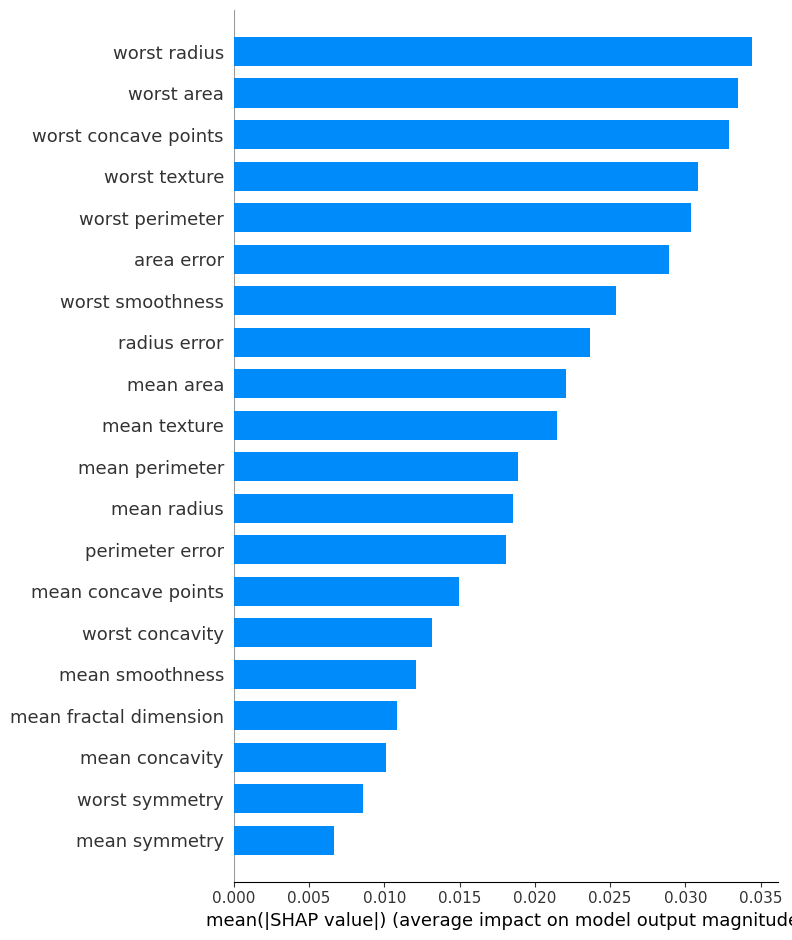

In [12]:
shap.initjs()

# Build and train the pipeline
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10, random_state=42)),
    ("lr", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

pipe.fit(X_train, y_train)

# Prepare background and samples to explain in original feature space
background = shap.sample(X_train, 80, random_state=42)  
X_explain = X_test.iloc[:50].copy()                     

# Wrap predict_proba to avoid SHAP trying to modify Pipeline.feature_names_in_
def predict_proba_fn(X):
    return pipe.predict_proba(X)

# Run KernelExplainer
kernel_explainer = shap.KernelExplainer(
    model=predict_proba_fn,
    data=background,
    feature_names=X_train.columns
)

shap_values_pipe = kernel_explainer.shap_values(X_explain, nsamples=200)

# Determine which column corresponds to benign (=1)
target_label = 1
class_idx = int(np.where(pipe.classes_ == target_label)[0][0])
print("pipe.classes_ =", pipe.classes_, "| using class_idx =", class_idx)

sv_benign = shap_to_2d(shap_values_pipe, class_idx=class_idx)

print("X_explain shape:", X_explain.shape)
print("sv_benign shape:", sv_benign.shape)

# If KernelExplainer returned an extra offset column, drop it
if sv_benign.shape[1] == X_explain.shape[1] + 1:
    sv_benign = sv_benign[:, :-1]
    print("Dropped extra offset column -> sv_benign shape:", sv_benign.shape)

# Plot global feature importance 
shap.summary_plot(
    sv_benign,
    X_explain,
    feature_names=X_explain.columns,
    plot_type="bar",
    show=True
)


This figure is a **SHAP summary bar plot**.  The x-axis shows **mean(|SHAP value|)**, the **average magnitude** of each feature’s contribution to the model output.

### Key observations

- **Dominant features are related to tumor size and sharp**
  - The most influential features include **`worst area`** (highest), `worst radius`, `worst perimeter`, as well as `radius error` and `area error`.
  - This suggests the model relies heavily on **size/scale-related measurements**.

- **Surface-related features are also important**
  - `worst texture`, `mean texture`, and `worst smoothness` rank high.
  - This indicates that **texture and smoothness information** contributes substantially to the classification.

- **Concavity and irregularity features matter but are slightly less dominant**
  - Features such as `worst concave points`, `worst concavity`, `mean concave points`, and `mean concavity` appear in the mid-to-high ranks.
  - These capture **boundary irregularity** and still provide meaningful predictive signal.

- **Relatively lower importance among the displayed features**
  - `mean fractal dimension` and `fractal dimension error` have smaller average SHAP magnitudes, implying weaker overall influence compared to the top-ranked features.

### Interpretation limits

1. **No directionality in this plot:** Because the plot uses **absolute SHAP values**, it does **not** tell whether a feature pushes predictions toward *benign* or *malignant*.

2. **Feature correlation:** Size-related variables (`radius`, `perimeter`, `area`) are often strongly correlated, so it is normal to see several of them ranked highly together.


## 4. Interprétation de 'mean radius'

In [13]:
# Plot dependence for "mean radius" 
shap.dependence_plot(
    "mean radius",
    sv,
    X_test_df,
    feature_names=X_test_df.columns,
    show=True
)


NameError: name 'sv' is not defined

This dependence plot shows how the feature **`mean radius`** affects the model output for `benign`. The y-axis is the **SHAP value** for `mean radius`.

### Key observation

- **Larger `mean radius` → more negative SHAP values:** Most points at higher `mean radius` lie around **-0.03 to -0.05**. `mean radius` **decreases** the model’s output for `benign`, thus pushing predictions **toward malignant (class 0)**.

- **Smaller `mean radius` (≈ 8–14) → mostly positive SHAP values:** SHAP values are often around **+0.01 to +0.02**. `mean radius` **increases** the model’s output for `benign`, pushing predictions **toward benign**.

- **Interaction with `worst compactness`:** The color scale suggests an interaction: at similar `mean radius`, **higher `worst compactness`** (redder points) tends to correspond to **more negative SHAP values**. This indicates that compactness/irregularity can **amplify the shift toward malignant** when `mean radius` is high.

